In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer



from imblearn.over_sampling import SMOTE

In [65]:
df = pd.read_csv('/content/loan.csv')

In [66]:
# loading and basic clean up

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [67]:
df.columns = [col.lower() for col in df.columns]
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [68]:
df = df.drop(columns='loan_id')

In [69]:
target = 'loan_status'

df[target] = df[target].map({
    "Y": 1,
    "N": 0
})

df.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [70]:
# handling missing values
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

In [71]:
X_train_process = X_train.copy()
X_test_process = X_test.copy()

In [72]:
# identify numerical col and categroical col

num_col = X_train.select_dtypes(include = np.number).columns.tolist()
cat_col = X_train.select_dtypes(exclude = np.number).columns.tolist()

In [73]:
num_col

['applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history']

In [74]:
cat_col

['gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'property_area']

In [75]:
num_col

['applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history']

In [76]:
X_train.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban
239,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban
448,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural
471,Male,Yes,1,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural
273,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban


In [77]:
# Handling missing values
if num_col:
  num_imputer = SimpleImputer(strategy='median')
  X_train_process[num_col] = num_imputer.fit_transform(X_train_process[num_col])
  X_test_process[num_col] = num_imputer.transform(X_test_process[num_col])


In [78]:
if cat_col:
  cat_imputer = SimpleImputer(strategy='most_frequent')
  X_train_process[cat_col] = cat_imputer.fit_transform(X_train_process[cat_col])
  X_test_process[cat_col] = cat_imputer.fit_transform(X_test_process[cat_col])

In [79]:
print("Test:", X_test_process.isnull().sum())
print("Train:", X_train_process.isnull().sum())

Test: gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64
Train: gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64


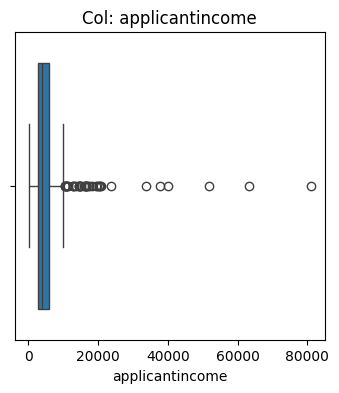

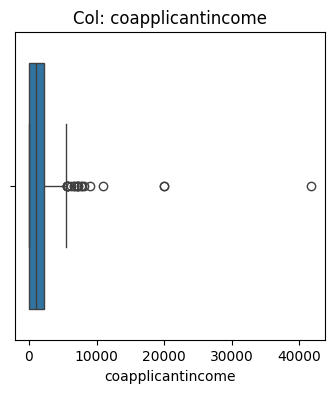

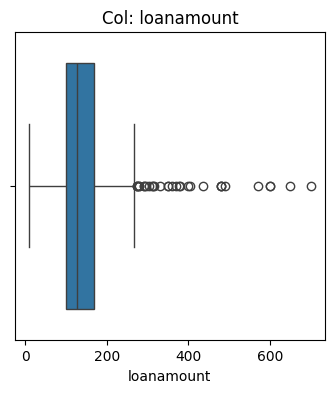

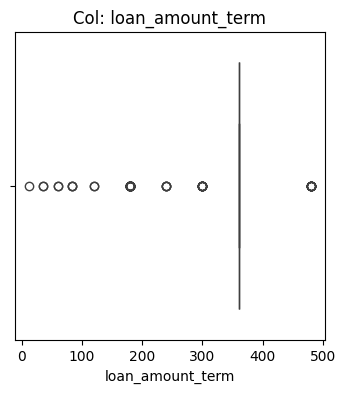

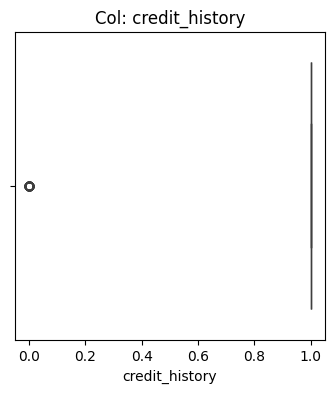

In [80]:
# Detecting outliers
for col in num_col:
  plt.figure(figsize=(4,4))
  sns.boxplot(x=X_train[col])
  plt.title(f"Col: {col}")
  plt.show()


In [81]:
# IQR

def iqr(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1
  upper = Q3 + 1.5 * IQR
  lower = Q1 - 1.5 * IQR

  return upper, lower
def compute_train_bound(df, col):
  bound = {}
  for i in col:
    high, low = iqr(df[i])
    bound[i] = (high, low)
  return bound

def cap_with_outliers(df, bound):
  capped_df = df.copy()
  for col, (high , low) in bound.items():
    capped_df[col] = np.where(capped_df[col] < high, high, capped_df[col])
    capped_df[col] = np.where(capped_df[col] > low, low, capped_df[col])

  return capped_df


In [82]:
# applicantincome, co-applicantincome, loanamount
outliers_col = ['applicantincome', 'coapplicantincome','loanamount']
train_bound = compute_train_bound(X_train_process, outliers_col)
train_capped = cap_with_outliers(X_train_process, train_bound)
test_capped = cap_with_outliers(X_test_process, train_bound)


print("Capped Outliers:")
print(train_capped)


Capped Outliers:
     gender married dependents     education self_employed  applicantincome  \
154    Male      No          0      Graduate            No          -1472.5   
239    Male     Yes          1      Graduate            No          -1472.5   
448    Male     Yes          2      Graduate            No          -1472.5   
471    Male     Yes          1  Not Graduate            No          -1472.5   
273    Male     Yes          0      Graduate            No          -1472.5   
..      ...     ...        ...           ...           ...              ...   
222    Male      No          0      Graduate            No          -1472.5   
349    Male     Yes          0      Graduate            No          -1472.5   
26     Male     Yes          0      Graduate            No          -1472.5   
96   Female     Yes          0      Graduate            No          -1472.5   
354  Female     Yes          0      Graduate            No          -1472.5   

     coapplicantincome  loanamount

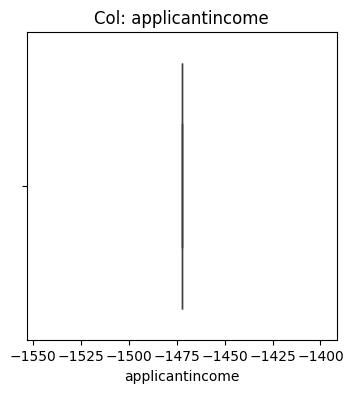

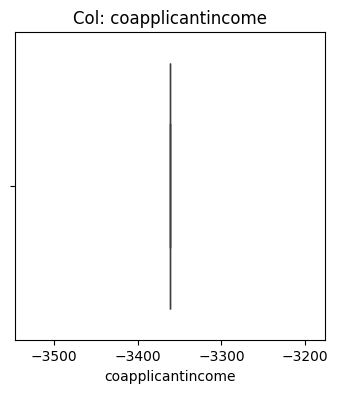

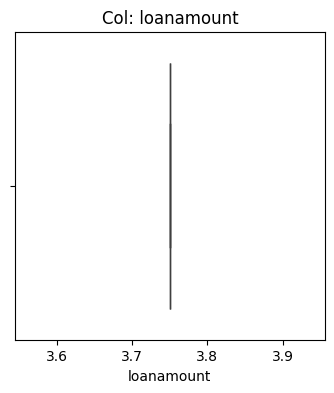

In [83]:
for col in outliers_col:
  plt.figure(figsize=(4,4))
  sns.boxplot(x=train_capped[col])
  plt.title(f"Col: {col}")
  plt.show()

In [84]:
for col in cat_col:
  print(f"{col}:")
  print(f"{X_train[col].unique()}")
  print("-"*50)

gender:
['Male' 'Female' nan]
--------------------------------------------------
married:
['No' 'Yes' nan]
--------------------------------------------------
dependents:
['0' '1' '2' nan '3+']
--------------------------------------------------
education:
['Graduate' 'Not Graduate']
--------------------------------------------------
self_employed:
['No' 'Yes' nan]
--------------------------------------------------
property_area:
['Urban' 'Semiurban' 'Rural']
--------------------------------------------------


In [85]:
label_enc_col = ['gender', 'education', 'dependents', 'self_employed']
one_hot_enc_col = ['property_area']

In [86]:
label_encoders = {}
for col in cat_col:
  le = LabelEncoder()
  le.fit(X_train[col])
  label_encoders[col] = le

  X_train_process[col] = le.transform(X_train_process[col])
  X_test_process[col] = le.transform(X_test_process[col])

In [87]:
print(label_encoders)

{'gender': LabelEncoder(), 'married': LabelEncoder(), 'dependents': LabelEncoder(), 'education': LabelEncoder(), 'self_employed': LabelEncoder(), 'property_area': LabelEncoder()}


In [88]:
for col in cat_col:
  print(X_train_process[col].value_counts())
  print("-"*50)

gender
1    404
0     87
Name: count, dtype: int64
--------------------------------------------------
married
1    322
0    169
Name: count, dtype: int64
--------------------------------------------------
dependents
0    284
1     85
2     83
3     39
Name: count, dtype: int64
--------------------------------------------------
education
0    380
1    111
Name: count, dtype: int64
--------------------------------------------------
self_employed
0    425
1     66
Name: count, dtype: int64
--------------------------------------------------
property_area
1    184
2    162
0    145
Name: count, dtype: int64
--------------------------------------------------


In [89]:
smt = SMOTE(random_state=42)
X_train_process, y_train_process = smt.fit_resample(X_train_process, y_train)

In [90]:
for col in cat_col:
  print(X_train_process[col].value_counts())
  print("-"*50)

gender
1    538
0    136
Name: count, dtype: int64
--------------------------------------------------
married
1    419
0    255
Name: count, dtype: int64
--------------------------------------------------
dependents
0    410
1    123
2    100
3     41
Name: count, dtype: int64
--------------------------------------------------
education
0    548
1    126
Name: count, dtype: int64
--------------------------------------------------
self_employed
0    602
1     72
Name: count, dtype: int64
--------------------------------------------------
property_area
1    264
0    232
2    178
Name: count, dtype: int64
--------------------------------------------------


In [92]:
scale_cols = ["applicantincome", "coapplicantincome", "loanamount", "loan_amount_term"]
scaler = StandardScaler()

scaler.fit(X_train_process[scale_cols])

X_train_process[scale_cols] = scaler.transform(X_train_process[scale_cols])
X_test_process[scale_cols] = scaler.transform(X_test_process[scale_cols])

In [93]:
X_train_process.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,1,0,0,0,0,-0.378851,-0.595284,-1.208446,0.267732,1.0,2
1,1,1,1,0,0,-0.368283,-0.595284,-0.635539,0.267732,1.0,1
2,1,1,2,0,0,-0.363953,0.076164,0.037004,0.267732,0.0,0
3,1,1,1,1,0,-0.482963,-0.006294,-0.423813,-2.660411,0.0,0
4,1,1,0,0,0,-0.488679,0.277599,0.037004,0.267732,1.0,1


In [94]:
print("Final Shape:")
print("X_TRAIN_PROCESS:", X_train_process.shape)
print("X_TEST_PROCESS:", X_test_process.shape)
print("Y_TRAIN_PROCESS:", y_train_process.shape)
print("Y_TEST_PROCESS:", y_test.shape)


Final Shape:
X_TRAIN_PROCESS: (674, 11)
X_TEST_PROCESS: (123, 11)
Y_TRAIN_PROCESS: (674,)
Y_TEST_PROCESS: (123,)
